# Aula 3: o switch na rede da planta

**Monitoria de Introdução às Redes de Comunicação, UFPE · 2026.2 · 3 horas**

Na última aula, dois CLPs trocaram dados por PUT/GET. Mas, se você ligasse o Wireshark no seu notebook, não veria nada dessa conversa. Hoje vocês descobrem por quê, e aprendem a configurar o equipamento que decide quem conversa com quem numa rede industrial: o **switch gerenciado**.

O laboratório vira uma fábrica com **três células**. Cada grupo é responsável por uma célula, com 2 CLPs e um bloco fixo de portas do switch.

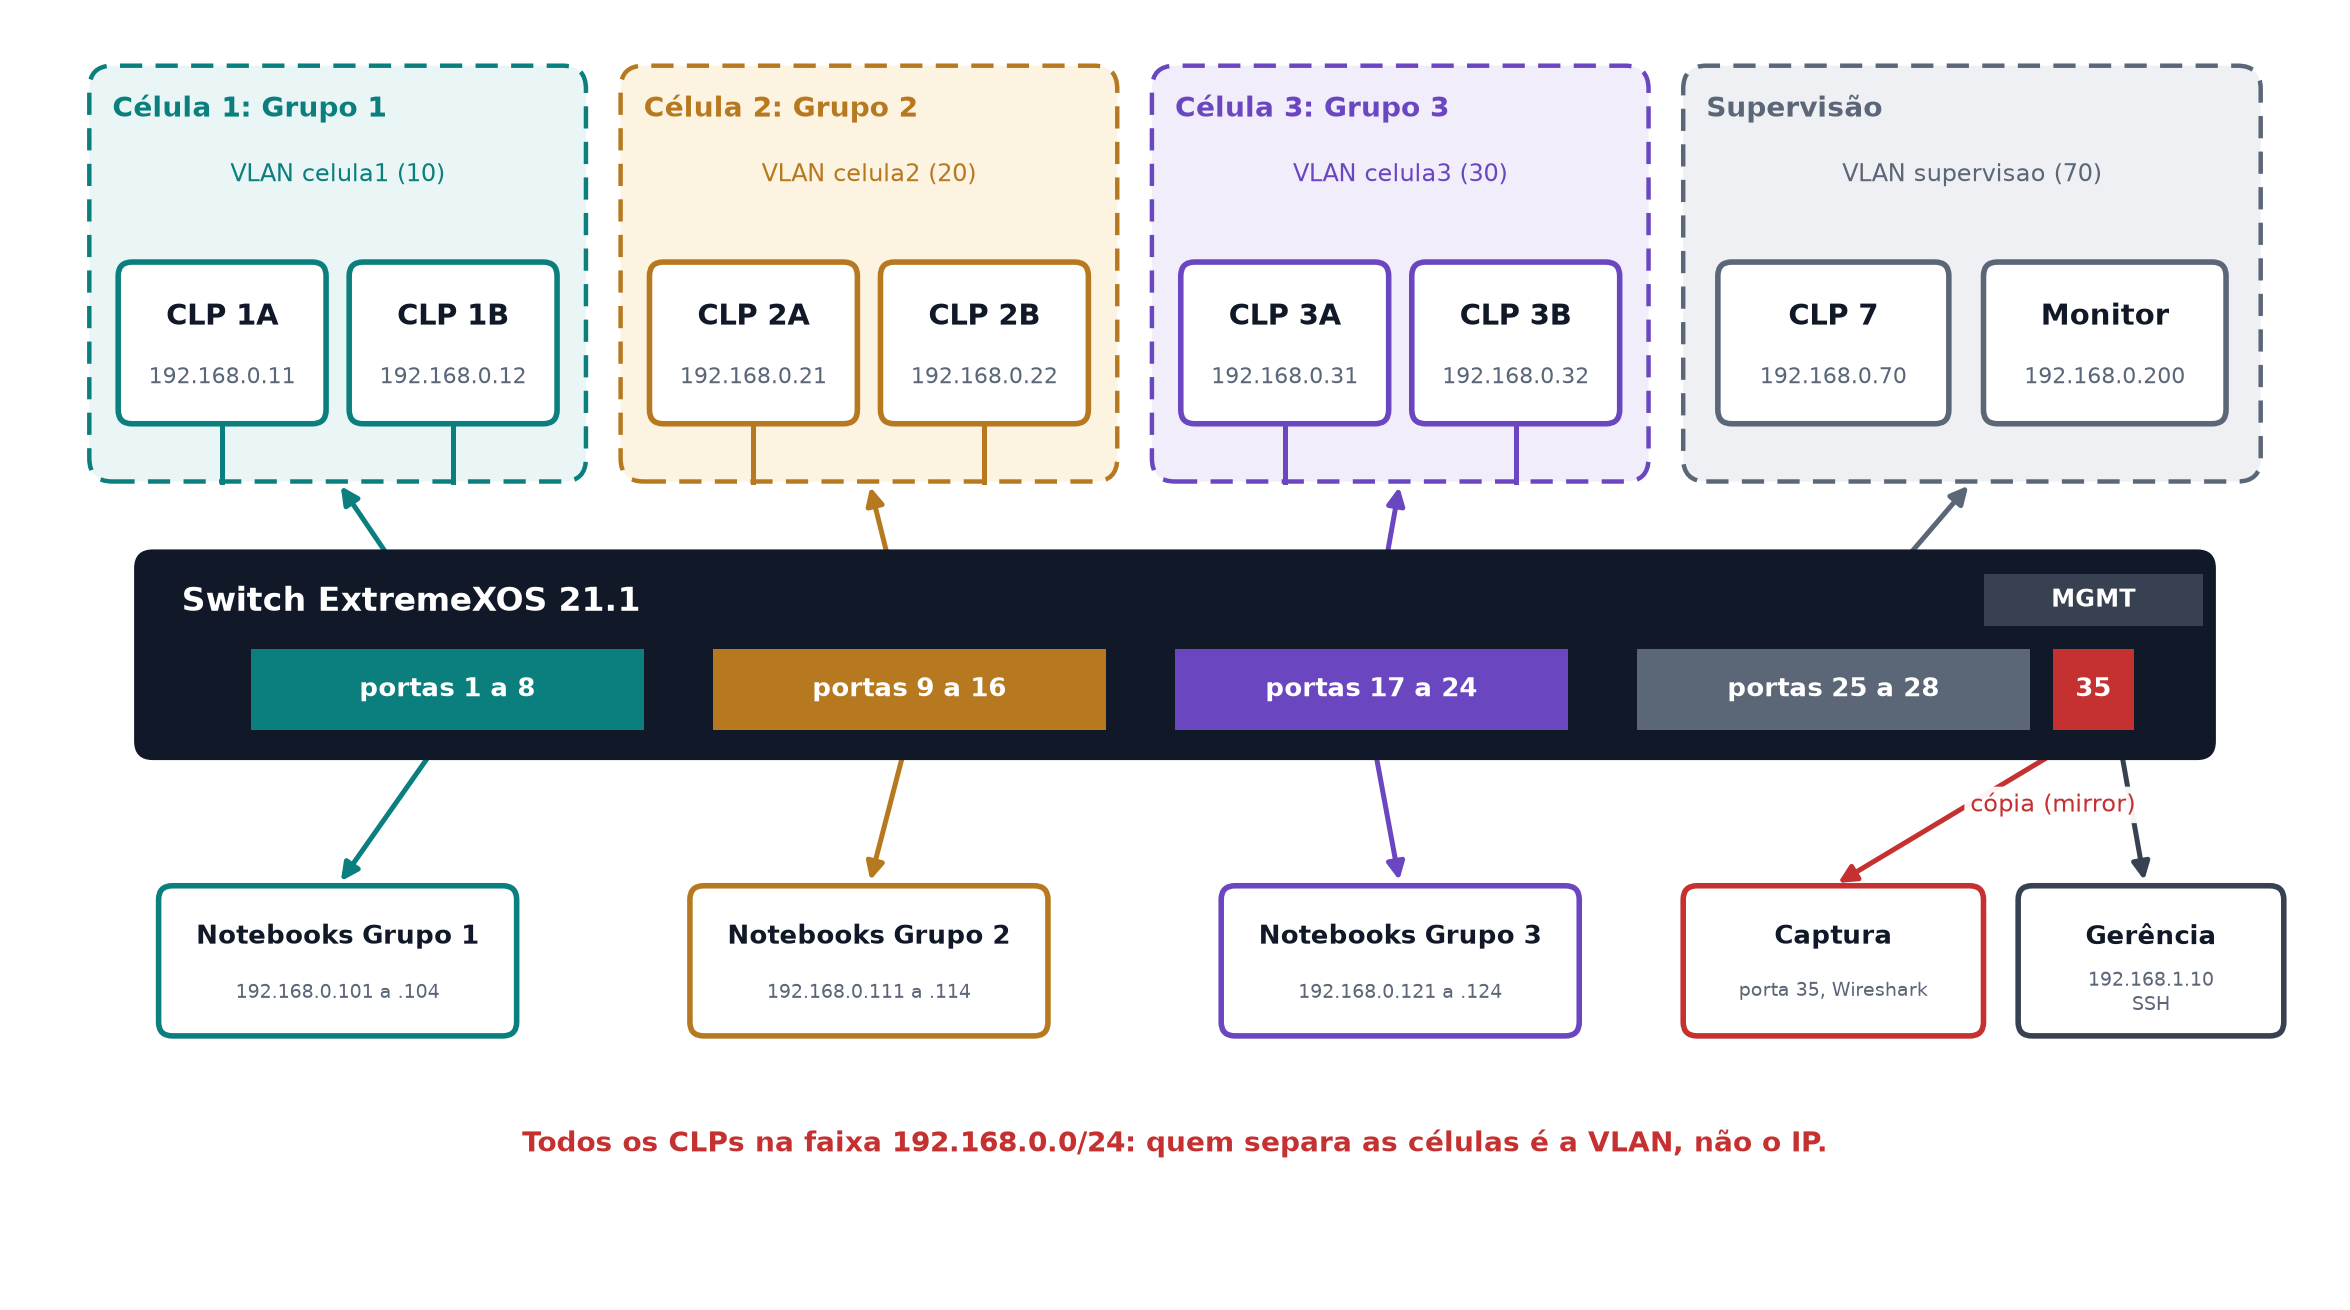

## Cronograma

| Horário | O que acontece |
|---|---|
| 0:00 a 0:30 | Aula: como o switch funciona, VLAN, espelhamento, segurança de porta |
| 0:30 a 0:40 | Grupos, mapa da bancada e ficha de comandos |
| 0:40 a 2:35 | **Projeto**: tarefas 0 a 4, com rodízio no switch |
| 2:35 a 2:55 | Apresentações (6 min por grupo) |
| 2:55 a 3:00 | Fechamento |

## Regras do switch

O switch é **um só** para a turma inteira. Um comando errado pode derrubar a célula de outro grupo. Por isso:

- cada grupo digita só comandos do **próprio bloco** de portas;
- os comandos são escritos **antes** na ficha, e o monitor confere;
- **ninguém** roda `save configuration`: no fim da aula o switch é reiniciado e volta ao que era;
- ninguém mexe na porta MGMT.

## A sua célula

| Célula | Portas | VLAN (tag) | CLP A | CLP B | Notebooks |
|---|---|---|---|---|---|
| Grupo 1 | 1 a 8 | `celula1` (10) | 192.168.0.11 | 192.168.0.12 | .101 a .104 |
| Grupo 2 | 9 a 16 | `celula2` (20) | 192.168.0.21 | 192.168.0.22 | .111 a .114 |
| Grupo 3 | 17 a 24 | `celula3` (30) | 192.168.0.31 | 192.168.0.32 | .121 a .124 |

Dentro do bloco, a ordem é sempre a mesma: **1ª porta** CLP A, **2ª** CLP B, **3ª a 6ª** notebooks, **7ª e 8ª** livres. Máscara de todos: `255.255.255.0`.

A porta **35** é a estação de captura (Wireshark), usada na tarefa 3.

Repare: os CLPs das três células estão na **mesma faixa de IP**. Hoje vocês vão mostrar que, mesmo assim, as células podem ficar completamente separadas.

## Rodízio no switch

| Rodada | Tarefa no switch | Grupo 1 | Grupo 2 | Grupo 3 |
|---|---|---|---|---|
| 1 | 1. Mapear e 2. Isolar | 0:45 | 0:58 | 1:11 |
| 2 | 3. Monitorar | 1:25 | 1:38 | 1:51 |
| 3 | 4. Endurecer | 2:05 | 2:15 | 2:25 |

Fora do seu turno: tarefa 0 (PUT/GET), escrever a ficha da próxima tarefa, analisar a captura.

## O que você precisa saber (resumo da aula)

### Como o switch aprende

Todo quadro Ethernet carrega o **MAC de origem** e o **MAC de destino**. O switch anota, numa tabela, em qual porta viu cada MAC de origem (a **FDB**, *forwarding database*). Quando precisa entregar um quadro, consulta a tabela e manda **só para a porta certa**. Se ainda não conhece o destino, copia para todas as portas (inundação).

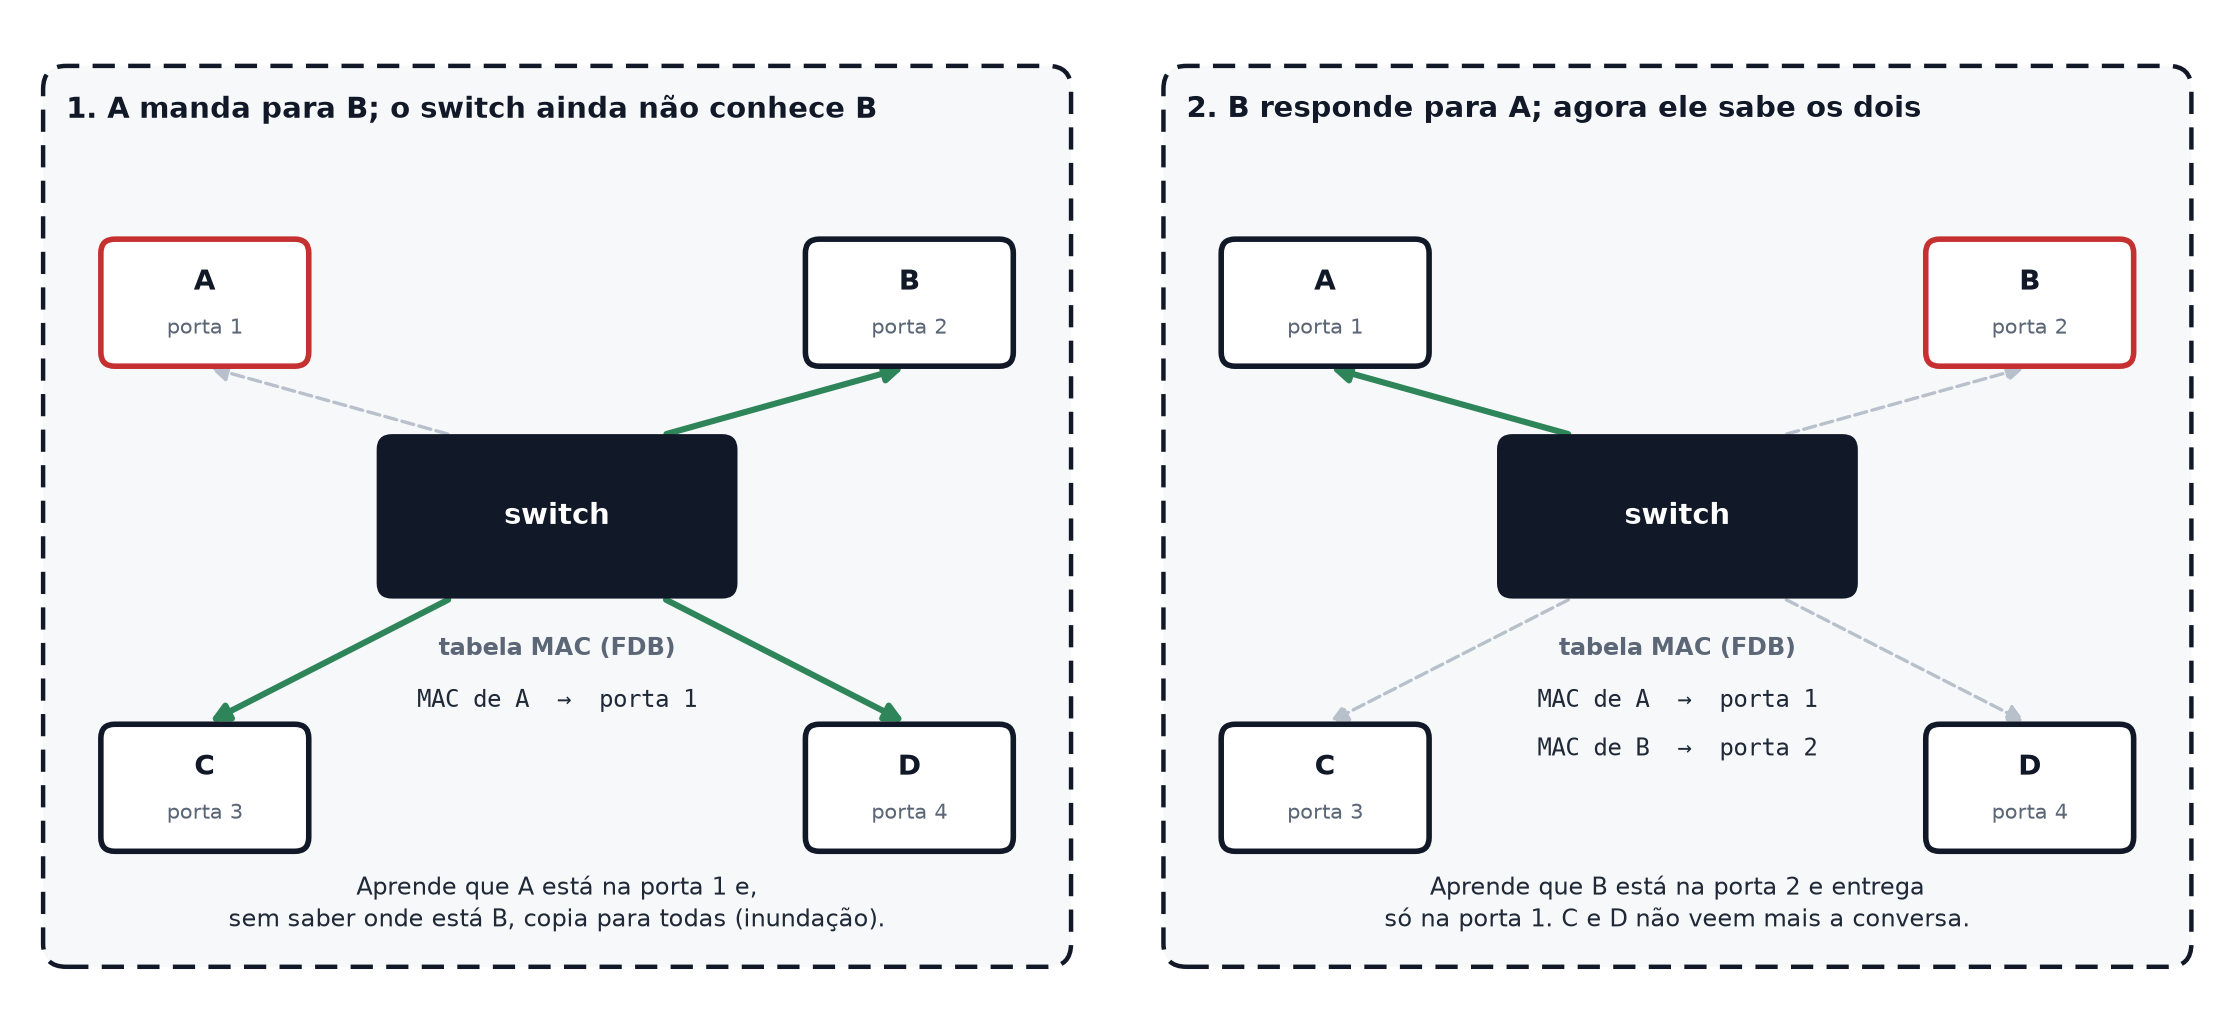

É por isso que o Wireshark do seu notebook não via o PUT/GET: os quadros entre os dois CLPs nunca são entregues na sua porta.

### VLAN

Uma **VLAN** divide um switch em vários switches lógicos. Portas em VLANs diferentes não trocam quadros, nem broadcast. Na prática, cada célula vira uma rede isolada, mesmo dividindo o mesmo equipamento.

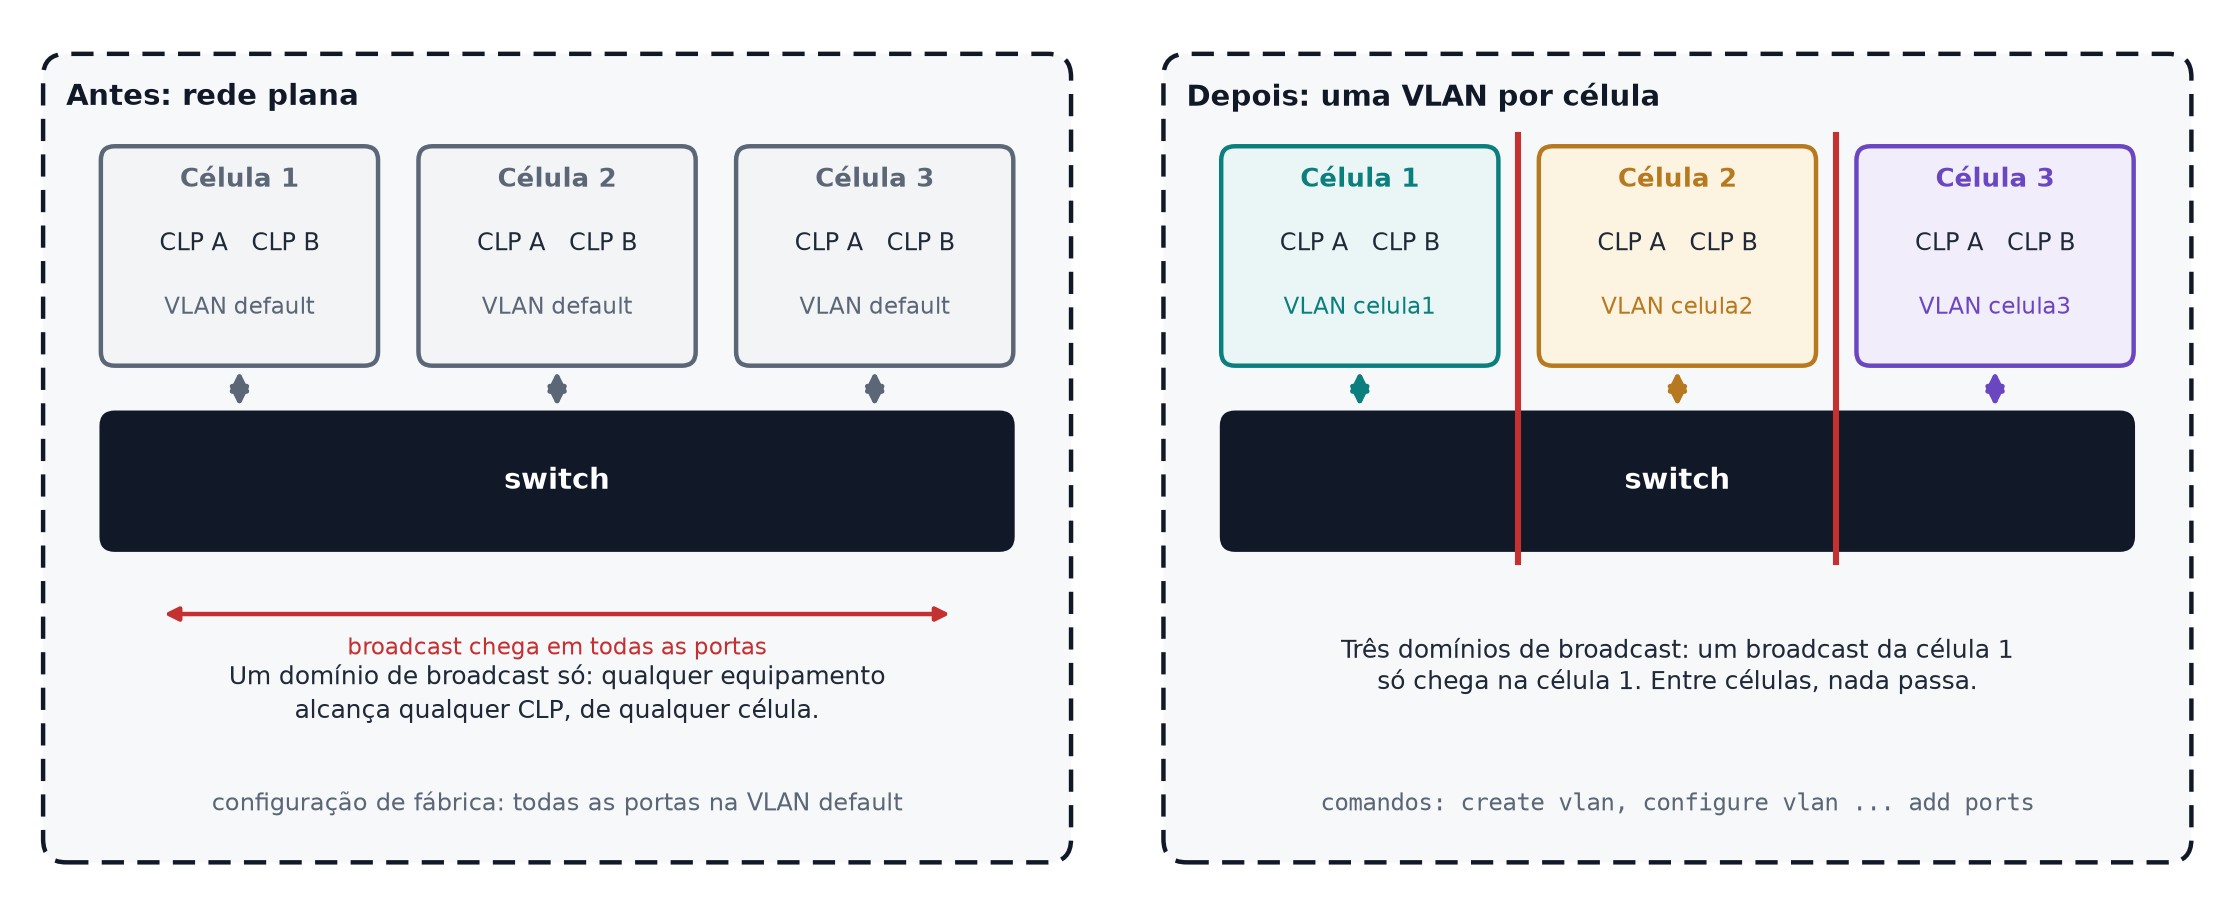

- Porta **sem tag** (*untagged*): pertence a uma VLAN só; o equipamento ligado nela nem sabe que VLAN existe. É o caso de CLPs e notebooks.
- Porta **com tag** (*tagged*): carrega várias VLANs, cada quadro marcado com o número dela (padrão 802.1Q). É usada entre switches.
- De fábrica, todas as portas estão na VLAN **default**.

### Espelhamento (*mirror*)

O switch pode copiar tudo o que passa numa porta para outra porta, onde fica um Wireshark. É assim que se monitora uma rede industrial sem atrapalhar a comunicação.

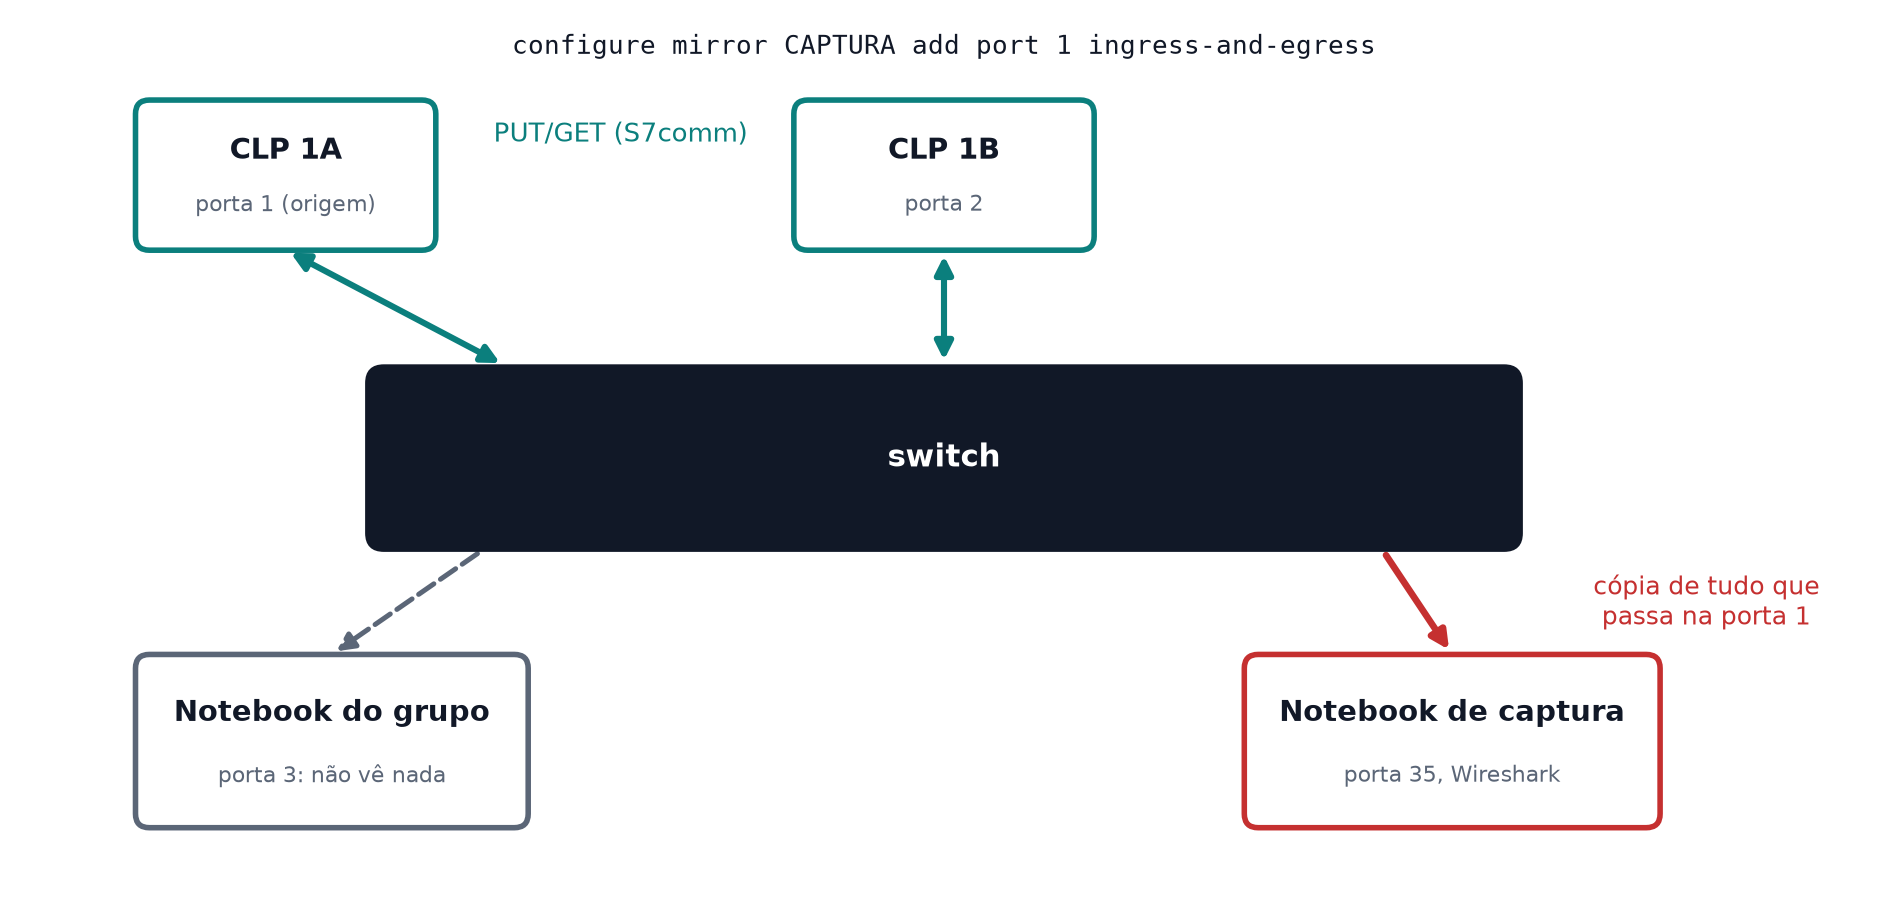

### Segurança de porta

- **Desligar portas livres:** ninguém pluga um notebook e entra na rede.
- **Limitar MACs por porta:** a porta do CLP só aceita o CLP; outro equipamento plugado no lugar dele é ignorado.

## Tarefa 0: PUT/GET entre os dois CLPs (fora do switch)

Comece por aqui, enquanto outro grupo usa o switch. É a mesma comunicação da aula passada, agora entre os dois CLPs da sua célula.

1. **IPs:** no TIA Portal, em cada CLP, Device configuration, porta PROFINET, Ethernet addresses: CLP A e CLP B com os IPs da tabela da sua célula. Carregue nos dois.
2. **Permitir o acesso:** no CLP que vai **ser lido ou escrito** (o parceiro), em Properties, Protection & Security, Connection mechanisms, marque **Permit access with PUT/GET communication from remote partner**.
3. **Dados:** no parceiro, um DB com algumas variáveis e **Optimized block access desmarcado** (o PUT/GET usa endereço absoluto, como `DB1.DBW0`).
4. **Blocos:** no outro CLP, as instruções **GET** e **PUT** (Communication, S7 Communication), com a conexão apontando para o IP do parceiro, e o `REQ` ligado a um pulso periódico (por exemplo um bit de clock memory).
5. Compile e carregue os dois.

**Prova:** na Watch Table, um valor mudado num CLP aparece no outro.

Dúvida de detalhe: é exatamente o que vocês fizeram na aula de PUT/GET; use o material dela.

## Como usar o switch no seu turno

O monitor abre o terminal do switch (SSH). No seu turno, um integrante digita os comandos da ficha já conferida.

- Os comandos são em inglês e começam pelo verbo: `show` (mostrar), `create` (criar), `configure` (configurar), `delete` (apagar), `enable` e `disable` (ligar e desligar).
- A tecla **Tab** completa o comando e mostra as opções possíveis.
- Comando errado não quebra nada: o switch responde com um erro. O perigo é o comando **certo** na porta **errada**. Por isso a ficha.

## Tarefa 1: mapear a célula

**Objetivo:** descobrir, pelo próprio switch, em que porta está cada equipamento da célula.

```
show fdb
show ports 1-8 information
```

(Grupo 2: portas 9-16; Grupo 3: portas 17-24.)

- `show fdb` lista cada MAC que o switch aprendeu, a VLAN e a **porta**.
- `show ports ... information` mostra quais portas têm link (algo plugado e ligado).

Para saber qual MAC é de qual CLP: o MAC aparece no TIA Portal (Online & diagnostics) e na etiqueta do CLP.

**Prova:** a tabela da tarefa 1 da ficha preenchida (porta, equipamento, MAC, IP).

**Para pensar:** desplugue o cabo de um notebook, espere um pouco e rode `show fdb` de novo. O MAC some na hora? (Dica: procure *aging* na saída.)

## Tarefa 2: isolar a célula

**Objetivo:** colocar a célula numa VLAN só dela, sem quebrar o PUT/GET.

Exemplo do Grupo 1 (troque portas, nome e tag para o seu grupo):

```
create vlan celula1
configure vlan celula1 tag 10
configure vlan default delete ports 1-8
configure vlan celula1 add ports 1-8 untagged
show vlan celula1
```

| Comando | Por quê |
|---|---|
| `create vlan celula1` | cria a VLAN |
| `configure vlan celula1 tag 10` | dá o número 802.1Q da VLAN |
| `configure vlan default delete ports 1-8` | tira as portas da VLAN default: uma porta sem tag só pode estar em **uma** VLAN |
| `configure vlan celula1 add ports 1-8 untagged` | põe as portas na VLAN nova, sem tag |
| `show vlan celula1` | confere o resultado |

**Provas:**
1. O PUT/GET entre os dois CLPs continua funcionando.
2. Do notebook do grupo, `ping` no CLP A da **sua** célula responde; `ping` num CLP de **outra** célula não responde.

**Para pensar:**
- Os IPs das três células estão na mesma faixa. Por que o `ping` para outra célula não funciona? (Pense no ARP: em qual VLAN o broadcast dele circula?)
- O que aconteceria se vocês esquecessem o `delete ports` da VLAN default?

## Tarefa 3: monitorar

**Objetivo:** ver o PUT/GET da célula no Wireshark, sem participar da conversa.

O switch só tem **uma** porta de monitoramento: a **35**, configurada no espelhamento chamado `CAPTURA`. No seu turno, você adiciona a porta de um CLP seu como origem do espelho.

Exemplo do Grupo 1 (CLP A na porta 1):

```
show mirror
configure mirror CAPTURA add port 1 ingress-and-egress
show mirror
```

`ingress-and-egress` copia o que **entra** e o que **sai** da porta.

No notebook da **porta 35**, abra o Wireshark, comece a captura e use o filtro:

```
s7comm
```

Abra um pacote e encontre:

| Campo | O que significa |
|---|---|
| ROSCTR: **Job** / **Ack_Data** | pedido de um CLP / resposta do outro |
| Function: **Read Var** / **Write Var** | GET (ler) / PUT (escrever) |
| Item: área **DB**, número do DB, endereço | qual memória foi lida ou escrita |
| Data | o valor transportado |

Salve a captura (*File, Save As*) num pendrive ou envie para o grupo.

**Antes de sair do switch, desfaça:**

```
configure mirror CAPTURA delete port 1
```

**Prova:** print de um pacote S7comm com os campos acima identificados.

**Para pensar:**
- Procure no pacote algum campo de senha ou de autenticação. Existe? O que isso significa para quem consegue espelhar uma porta?
- Por que o notebook do grupo, na porta 3, não vê nada disso, mesmo com o espelho ligado?

## Tarefa 4: endurecer

**Objetivo:** fechar a célula contra equipamentos que não deveriam estar ali.

Exemplo do Grupo 1:

```
disable port 7-8
configure ports 1 vlan celula1 limit-learning 1
configure ports 2 vlan celula1 limit-learning 1
show fdb
```

- `disable port 7-8` desliga as portas livres do bloco.
- `limit-learning 1` faz a porta do CLP aceitar **um** MAC só. Um MAC a mais é descartado.

**Provas:**
1. Notebook plugado na porta 7: sem link.
2. Desplugue o CLP A, plugue um notebook na porta dele e tente `ping` em qualquer coisa: não funciona. Recoloque o CLP: volta a funcionar.

**Para pensar:**
- Que tipo de ataque essa configuração dificulta?
- Ela impede alguém que copie o MAC do CLP? (Pesquise: *MAC spoofing*.)

## Extra: a supervisão

O CLP 7, da supervisão, precisa ler um valor de cada célula. Desenhe como isso poderia funcionar **sem** juntar as células de novo numa rede só. Que equipamento ou função faria a ponte, e o que ela deveria deixar passar?

(Dica: é o *conduto* do modelo Purdue da Aula 2.)

## Apresentação (6 minutos por grupo)

1. O mapa da célula (tarefa 1).
2. A prova do isolamento: PUT/GET dentro da célula funcionando, `ping` para fora falhando.
3. Um pacote S7comm explicado.
4. A prova do endurecimento.
5. Uma frase: o que essa configuração protege numa fábrica de verdade?

## Quando algo não funciona

| Sintoma | Causa provável | O que fazer |
|---|---|---|
| `show fdb` não mostra o CLP | cabo, CLP desligado, ou ele ainda não mandou nada | ping no CLP a partir do notebook e rode de novo |
| Depois da VLAN, o PUT/GET parou | uma das portas dos CLPs ficou fora da VLAN | `show vlan celulaN` e confira as portas |
| `ping` dentro da célula parou | o notebook está numa porta fora do bloco | confira a porta no mapa |
| `ping` para outra célula ainda responde | as portas continuam na VLAN default | faltou o `delete ports` da default |
| Wireshark na porta 35 vazio | porta errada como origem, ou espelho desabilitado | `show mirror` |
| Nada aparece com o filtro `s7comm` | o PUT/GET não está rodando | confira a tarefa 0 |
| Notebook não pega rede em nenhuma porta | porta desligada (`disable port`) ou limite de MAC | confira com o monitor |